###Importing libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
df = pd.read_csv('my_data.csv')
df.head(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165000,137000,472000,New York,209200
1,160000,151000,445000,California,202800
2,155000,102000,420000,Florida,197300
3,150000,119000,400000,New York,191900
4,145000,92000,385000,Florida,185300


In [3]:
X = df.iloc[:, :-1].values
y = df.iloc[:,-1].values

In [4]:
y

array([209200, 202800, 197300, 191900, 185300, 180000, 174600, 169600,
       165400, 160000, 155100, 150000, 145600, 141300, 137500, 132900,
       128800, 124700, 120500, 116800, 113900, 111300, 108600, 106000,
       103100, 100600,  97900,  95200,  92800,  90100,  87800,  85200,
        82900,  80500,  78200,  75900,  73600,  71200,  69000,  66600,
        64200,  62000,  59600,  57300,  54900,  52600,  50200,  47800,
        45400,  43100])

In [5]:
df.iloc[0:3,:]

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165000,137000,472000,New York,209200
1,160000,151000,445000,California,202800
2,155000,102000,420000,Florida,197300


In [6]:
df["zeroes"] = [0 for i in range(len(df))]

In [7]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit,zeroes
0,165000,137000,472000,New York,209200,0
1,160000,151000,445000,California,202800,0
2,155000,102000,420000,Florida,197300,0
3,150000,119000,400000,New York,191900,0
4,145000,92000,385000,Florida,185300,0
5,140000,101000,370000,California,180000,0
6,136000,148000,355000,Florida,174600,0
7,132000,146000,340000,New York,169600,0
8,128000,149000,330000,California,165400,0
9,124000,109000,315000,Florida,160000,0


In [8]:
def fx(a):
    return a+1

df["zeroes"] = df["zeroes"].apply(fx)

In [9]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit,zeroes
0,165000,137000,472000,New York,209200,1
1,160000,151000,445000,California,202800,1
2,155000,102000,420000,Florida,197300,1
3,150000,119000,400000,New York,191900,1
4,145000,92000,385000,Florida,185300,1
5,140000,101000,370000,California,180000,1
6,136000,148000,355000,Florida,174600,1
7,132000,146000,340000,New York,169600,1
8,128000,149000,330000,California,165400,1
9,124000,109000,315000,Florida,160000,1


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [11]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
#feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

print(r2_score(y_test, y_pred))

0.9993942327719232


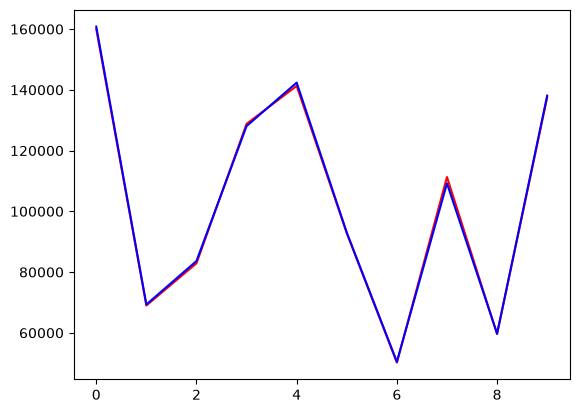

In [15]:
plt.plot(y_test, color="red")
plt.plot(y_pred, color="blue")